<a href="https://colab.research.google.com/github/bintadas/Book_Class_Assignment/blob/main/Traffic_Sign_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset"

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATASET_PATH}"
    )


Dataset path: /content/drive/MyDrive/Train_Dataset/traffic_sign_dataset
Exists: True


In [ ]:
!find /content/drive/MyDrive/Train_Dataset/traffic_sign_dataset -maxdepth 2 -type d | sort -V


/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Meta
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Test
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/0
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/1
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/2
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/3
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/4
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/5
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/6
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/7
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/8
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/9
/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train/10
/content/drive/MyDrive/Tr

In [ ]:
DATASET_DIR = '/content/drive/MyDrive/Train_Dataset/traffic_sign_dataset'

TRAIN_DIR = os.path.join(DATASET_DIR, 'Train')
TEST_DIR = os.path.join(DATASET_DIR, 'Test')

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))


Train directory: /content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Train
Test directory: /content/drive/MyDrive/Train_Dataset/traffic_sign_dataset/Test
Train exists: True
Test exists: True


In [ ]:
IMG_SIZE = 64

print("Image size for resizing:", IMG_SIZE)

Image size for resizing: 64


In [ ]:
train_classes = sorted(
    [
        folder for folder in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, folder))
    ],
    key=int
)

test_classes = sorted(
    [
        folder for folder in os.listdir(TEST_DIR)
        if os.path.isdir(os.path.join(TEST_DIR, folder))
    ],
    key=int
)

print("Number of training classes:", len(train_classes))

print(train_classes)



Number of training classes: 43
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


In [ ]:
class_counts = {}

for class_name in train_classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[class_name] = count

print("Images per class:")

for class_name, count in class_counts.items():
    print(f"Class {class_name}: {count}")


Images per class:
Class 0: 210
Class 1: 2220
Class 2: 2250
Class 3: 1410
Class 4: 1980
Class 5: 1860
Class 6: 420
Class 7: 1440
Class 8: 1410
Class 9: 1470
Class 10: 2010
Class 11: 1320
Class 12: 2100
Class 13: 2160
Class 14: 780
Class 15: 630
Class 16: 420
Class 17: 1110
Class 18: 1200
Class 19: 210
Class 20: 360
Class 21: 330
Class 22: 390
Class 23: 510
Class 24: 270
Class 25: 1500
Class 26: 600
Class 27: 240
Class 28: 540
Class 29: 270
Class 30: 450
Class 31: 780
Class 32: 240
Class 33: 689
Class 34: 420
Class 35: 1200
Class 36: 390
Class 37: 210
Class 38: 2070
Class 39: 300
Class 40: 360
Class 41: 240
Class 42: 240


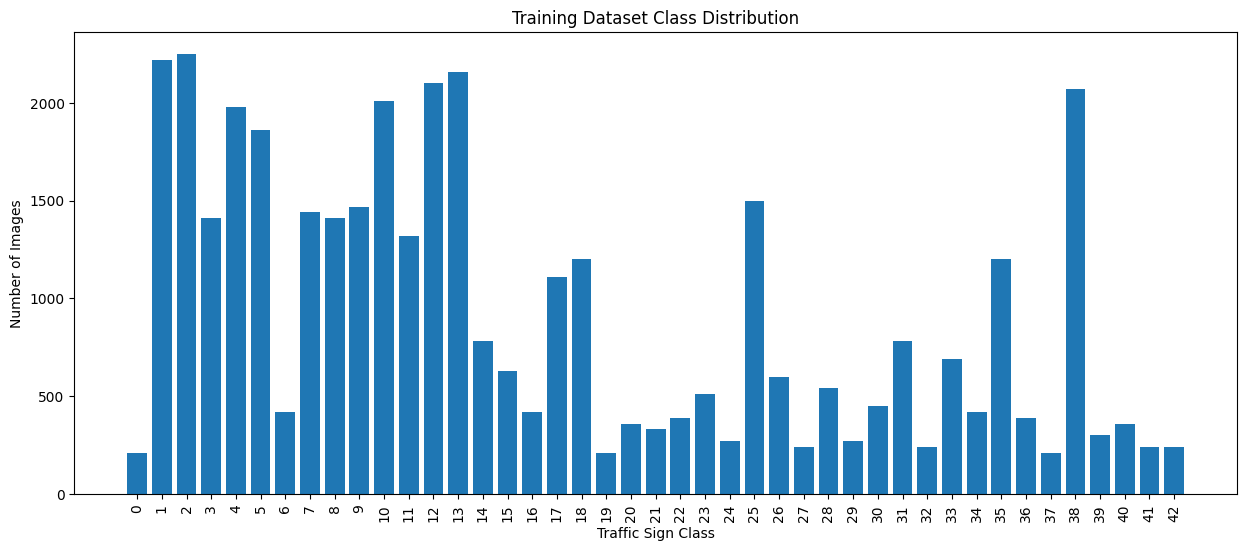

In [ ]:
plt.figure(figsize=(15, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Traffic Sign Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=90)

plt.show()


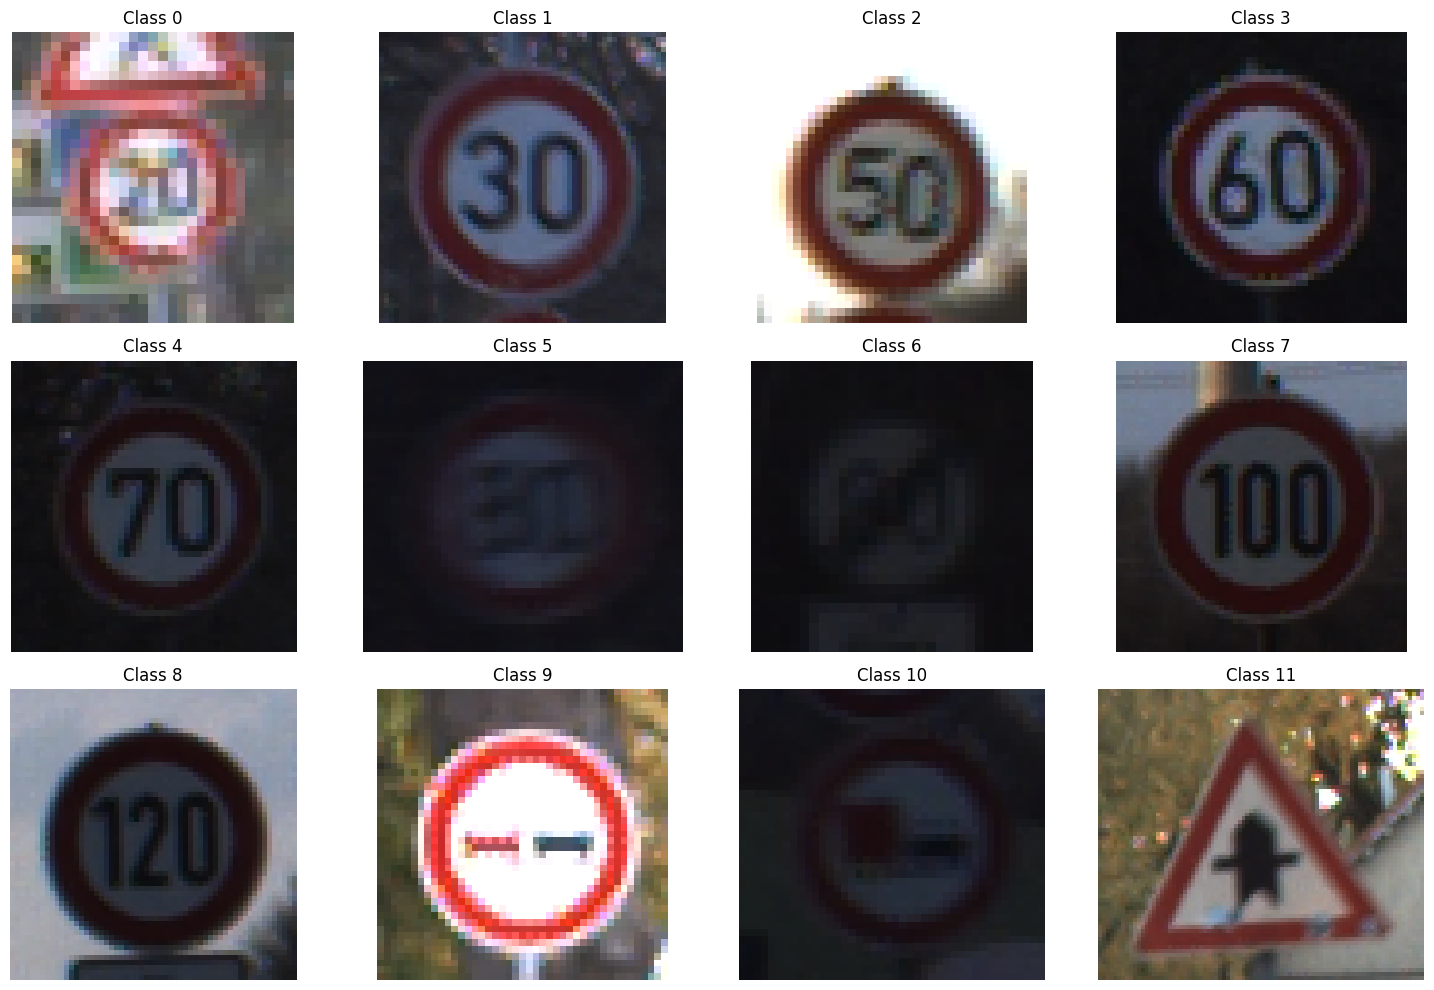

In [ ]:
plt.figure(figsize=(15, 10))

num_classes_to_show = min(len(train_classes), 12)

for i, class_name in enumerate(train_classes[:num_classes_to_show]):

    class_path = os.path.join(TRAIN_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    if len(images) == 0:
        continue

    image_path = os.path.join(class_path, images[0])

    image = plt.imread(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Class {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
image_sizes = []

for class_id in train_classes:

    class_path = os.path.join(
        TRAIN_DIR,
        class_id
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".ppm")
        )
    ]

    for image_name in image_files[:20]:

        image_path = os.path.join(
            class_path,
            image_name
        )

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)

        except:
            pass

print("Number of sampled images:", len(image_sizes))
print("First 20 sizes:", image_sizes[:20])

Number of sampled images: 860
First 20 sizes: [(29, 30), (30, 30), (30, 30), (31, 31), (30, 32), (31, 31), (33, 34), (34, 35), (33, 34), (36, 36), (35, 36), (37, 38), (37, 38), (40, 39), (41, 42), (44, 44), (46, 44), (47, 48), (50, 48), (53, 51)]


In [ ]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width: 25
Maximum width: 176
Minimum height: 25
Maximum height: 175


In [ ]:
X = []

y = []

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".ppm"
)

for class_id in train_classes:

    class_path = os.path.join(
        TRAIN_DIR,
        class_id
    )

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(valid_extensions):
            continue

        image_path = os.path.join(
            class_path,
            image_name
        )

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image = image.resize(
                (IMG_SIZE, IMG_SIZE)
            )

            X.append(
                np.array(image)
            )

            y.append(
                int(class_id)
            )

        except Exception as e:

            print(
                "Error:",
                image_path,
                e
            )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39209, 64, 64, 3)
y shape: (39209,)


In [ ]:
print("Data type:", X.dtype)
print("Minimum pixel:", X.min())
print("Maximum pixel:", X.max())
print("Labels:", np.unique(y))

Data type: uint8
Minimum pixel: 0
Maximum pixel: 255
Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [ ]:
X = X.astype("float32") / 255.0

print("Minimum pixel:", X.min())
print("Maximum pixel:", X.max())

Minimum pixel: 0.0
Maximum pixel: 1.0


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 20


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (25093, 64, 64, 3)
Validation: (6274, 64, 64, 3)
Testing: (7842, 64, 64, 3)


In [ ]:
print(
    "Training classes:",
    len(np.unique(y_train))
)

print(
    "Validation classes:",
    len(np.unique(y_val))
)

print(
    "Testing classes:",
    len(np.unique(y_test))
)

Training classes: 43
Validation classes: 43
Testing classes: 43


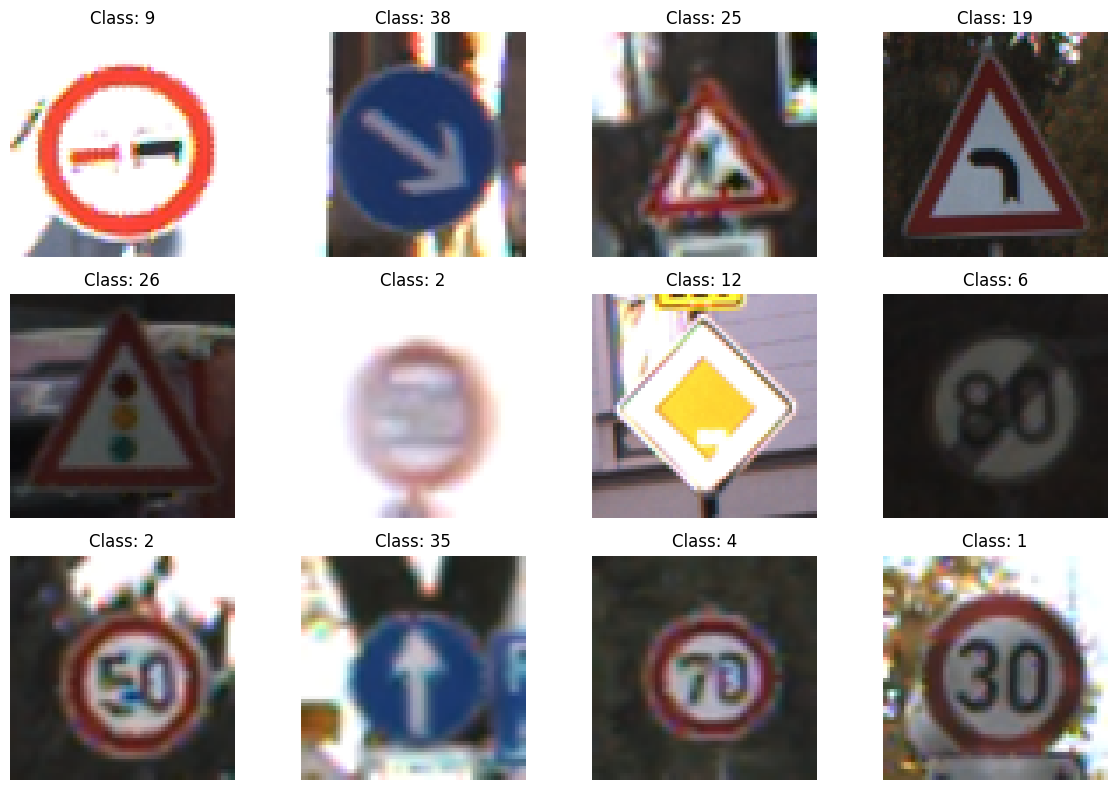

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_train[i])

    plt.title(
        f"Class: {y_train[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
NUM_CLASSES = len(np.unique(y))

print("Number of classes:", NUM_CLASSES)

build_cnn = keras.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.5
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

build_cnn.summary()

Number of classes: 43


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
build_cnn.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

In [ ]:
BATCH_SIZE = 64
EPOCHS = 5
history = build_cnn.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 209s 524ms/step - accuracy: 0.4231 - loss: 2.0781 - val_accuracy: 0.8471 - val_loss: 0.5576
Epoch 2/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 187s 476ms/step - accuracy: 0.7956 - loss: 0.6523 - val_accuracy: 0.9538 - val_loss: 0.1952
Epoch 3/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 210s 497ms/step - accuracy: 0.8766 - loss: 0.3778 - val_accuracy: 0.9794 - val_loss: 0.1036
Epoch 4/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 192s 473ms/step - accuracy: 0.9103 - loss: 0.2727 - val_accuracy: 0.9860 - val_loss: 0.0676
Epoch 5/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 202s 473ms/step - accuracy: 0.9282 - loss: 0.2140 - val_accuracy: 0.9828 - val_loss: 0.0578


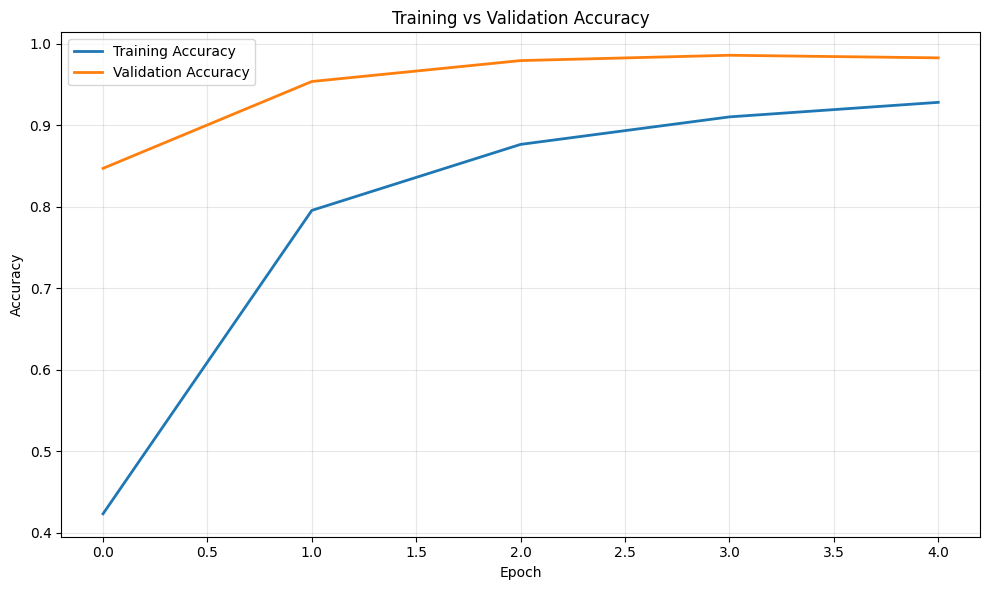

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

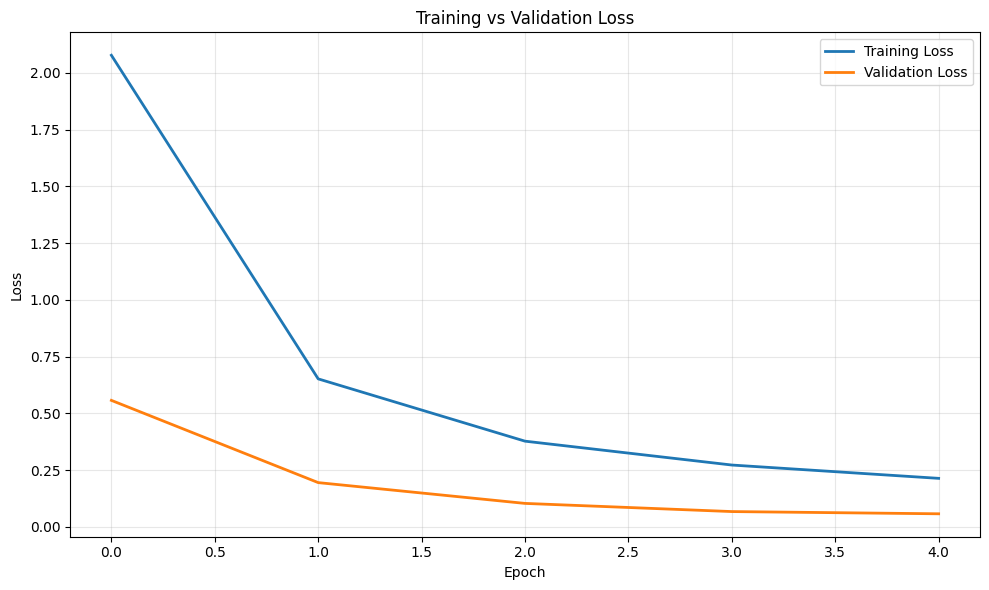

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_accuracy = build_cnn.evaluate(
    X_val,
    y_val,
    verbose=1
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)

print(
    f"Validation Loss: "
    f"{val_loss:.4f}"
)

197/197 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.9828 - loss: 0.0578
Validation Accuracy: 98.28%
Validation Loss: 0.0578


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/cnn_model.keras"

build_cnn.save(MODEL_PATH)

print(
    "Model saved:",
    MODEL_PATH
)

Model saved: /content/drive/MyDrive/cnn_model.keras


In [ ]:
test_loss, test_accuracy = build_cnn.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(
    f"Dataset 1(German Traffic Sign Recognition Dataset) Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Dataset 1(German Traffic Sign Recognition Dataset) Test Loss: "
    f"{test_loss:.4f}"
)

246/246 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.9869 - loss: 0.0503
Dataset 1(German Traffic Sign Recognition Dataset) Test Accuracy: 98.69%
Dataset 1(German Traffic Sign Recognition Dataset) Test Loss: 0.0503


In [ ]:
NEW_DATASET_PATH = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"

print("NEW Dataset path:", NEW_DATASET_PATH)
print("Exists:", os.path.exists(NEW_DATASET_PATH))

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{NEW_DATASET_PATH}"
    )


NEW Dataset path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)
Exists: True


In [ ]:
for root, dirs, files_list in os.walk(
    NEW_DATASET_PATH
):

    print("\nFolder:", root)

    if files_list:
        print(
            "Example:",
            files_list[:5]
             )


Folder: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)

Folder: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)

Folder: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test
Example: ['Left_turn_297_jpg.rf.3de153fd6b11497c2747284cd3cd95e2.jpg', 'Emergency_break_109_jpg.rf.a2423816ecf91dfd089b2f8384ea8b0a.jpg', 'Emergency_break_128_jpg.rf.45d7794122b8020852398d8a564854d9.jpg', 'Emergency_break_48_jpg.rf.d7558976793d0e6694c90071934c1fcf.jpg', 'Hospital_ahead_11_jpg.rf.13f9cb051af73967ec4104b8e0a374e8.jpg']

Folder: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/train
Example: ['Speed_limit_40km_256_jpg.rf.5e59471cf6e9e96ed8dd103c52cdd1c9.jpg', 'Speed_limit_40km_319_jpg.rf.6c7d1a9297de94a8e91843f813081ce8.jpg', 'Speed_limit_40km_393_jpg.rf.95c1e25e5ba8857f51ee2d2bf50a6e70.jpg', 'Speed_limit_40km_373_jpg.rf.73801207b19c4267328692c598da77ac.jpg', 'Speed_limit_40km_352_jpg.rf.6

In [ ]:
Train_Dataset_CLASSES = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

print("Number of Train Dataset Classes:", len(Train_Dataset_CLASSES))

Number of Train Dataset Classes: 43


In [ ]:
mapping_df = pd.DataFrame(
    list(Train_Dataset_CLASSES.items()),
    columns=["Class ID", "Class Name"]
)

mapping_df

,Class ID,Class Name
0,0,Speed limit 20 km/h
1,1,Speed limit 30 km/h
2,2,Speed limit 50 km/h
3,3,Speed limit 60 km/h
4,4,Speed limit 70 km/h
5,5,Speed limit 80 km/h
6,6,End of speed limit 80 km/h
7,7,Speed limit 100 km/h
8,8,Speed limit 120 km/h
9,9,No passing


In [ ]:
for class_id, class_name in Train_Dataset_CLASSES.items():
    print(f"{class_id:2d} → {class_name}")

 0 → Speed limit 20 km/h
 1 → Speed limit 30 km/h
 2 → Speed limit 50 km/h
 3 → Speed limit 60 km/h
 4 → Speed limit 70 km/h
 5 → Speed limit 80 km/h
 6 → End of speed limit 80 km/h
 7 → Speed limit 100 km/h
 8 → Speed limit 120 km/h
 9 → No passing
10 → No passing for vehicles over 3.5 tons
11 → Right-of-way at the next intersection
12 → Priority road
13 → Yield
14 → Stop
15 → No vehicles
16 → Vehicles over 3.5 tons prohibited
17 → No entry
18 → General caution
19 → Dangerous curve left
20 → Dangerous curve right
21 → Double curve
22 → Bumpy road
23 → Slippery road
24 → Road narrows on the right
25 → Road work
26 → Traffic signals
27 → Pedestrians
28 → Children crossing
29 → Bicycles crossing
30 → Beware of ice/snow
31 → Wild animals crossing
32 → End of all speed and passing limits
33 → Turn right ahead
34 → Turn left ahead
35 → Ahead only
36 → Go straight or right
37 → Go straight or left
38 → Keep right
39 → Keep left
40 → Roundabout mandatory
41 → End of no passing
42 → End of no 

In [ ]:
NEW_DATASET_PATH = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"

In [ ]:


model = build_cnn

print("Model ready for Dataset 2(BRSDD) testing.")
print("Model input shape :", model.input_shape)
print("Model output shape:", model.output_shape)

Model ready for Dataset 2(BRSDD) testing.
Model input shape : (None, 64, 64, 3)
Model output shape: (None, 43)


In [ ]:


gtsrb_probabilities = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

gtsrb_y_pred = np.argmax(
    gtsrb_probabilities,
    axis=1
)

gtsrb_y_true = y_test.astype(int)

print("Dataset 1 true labels :", len(gtsrb_y_true))
print("Dataset 1 predictions :", len(gtsrb_y_pred))

123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step
Dataset 1 true labels : 7842
Dataset 1 predictions : 7842


In [ ]:


dataset1_accuracy = accuracy_score(
    gtsrb_y_true,
    gtsrb_y_pred
)

print(
    f"Dataset 1 Test Accuracy: "
    f"{dataset1_accuracy * 100:.2f}%"
)

Dataset 1 Test Accuracy: 98.69%


In [ ]:


print(
    classification_report(
        gtsrb_y_true,
        gtsrb_y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.8095    0.8947        42
           1     0.9800    0.9955    0.9877       444
           2     0.9978    0.9867    0.9922       450
           3     0.9926    0.9504    0.9710       282
           4     0.9949    0.9874    0.9911       396
           5     0.9433    0.9839    0.9632       372
           6     1.0000    1.0000    1.0000        84
           7     0.9861    0.9861    0.9861       288
           8     0.9754    0.9858    0.9806       282
           9     1.0000    1.0000    1.0000       294
          10     0.9950    0.9975    0.9963       402
          11     1.0000    0.9962    0.9981       264
          12     1.0000    1.0000    1.0000       420
          13     0.9977    1.0000    0.9988       432
          14     1.0000    0.9936    0.9968       156
          15     0.9843    0.9921    0.9881       126
          16     1.0000    1.0000    1.0000        84
          17     0.9955    

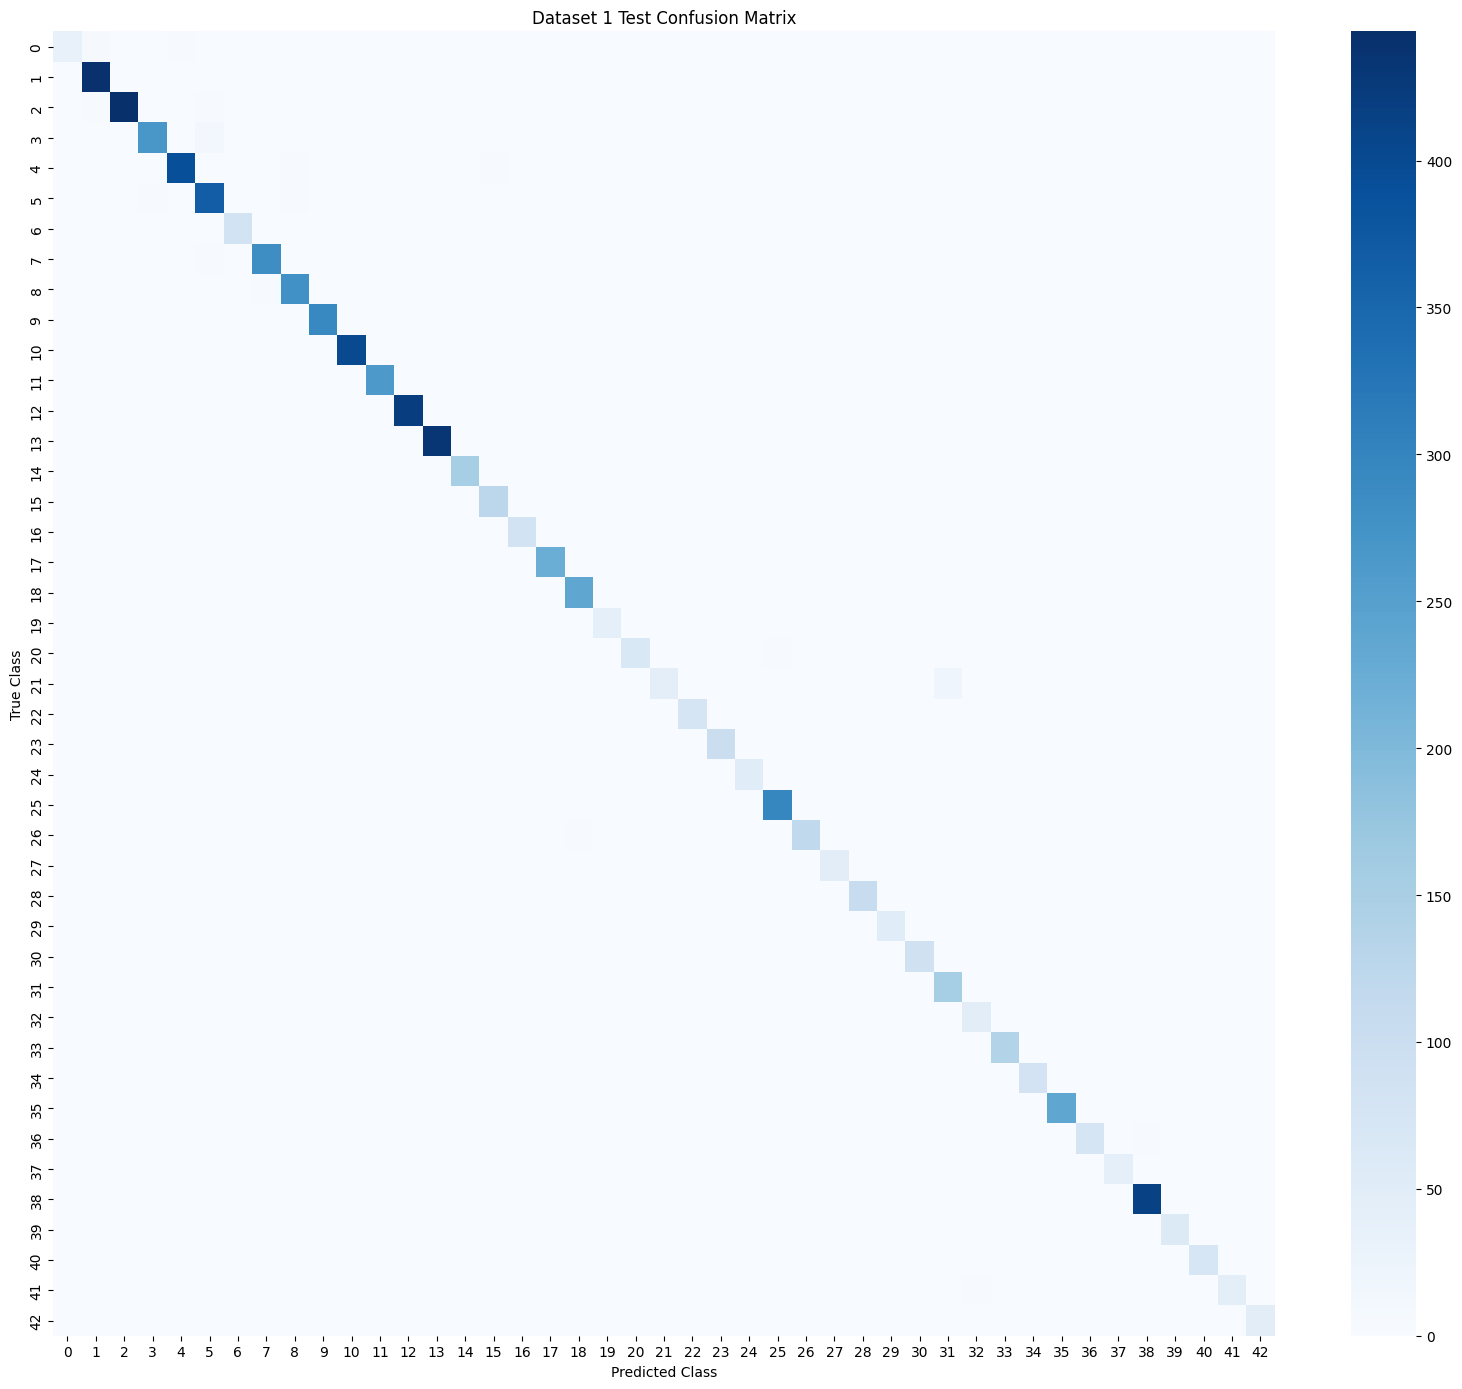

In [ ]:


cm_gtsrb = confusion_matrix(
    gtsrb_y_true,
    gtsrb_y_pred
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm_gtsrb,
    cmap="Blues",
    annot=False,
    fmt="d"
)

plt.title("Dataset 1 Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
BRSDD_PATH = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"
BRSDD_TEST_PATH = os.path.join(
    BRSDD_PATH,
    "BRSDD (Tensorflow version)",
    "test"
)

ANNOTATIONS_PATH = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test/_annotations.csv"

MODEL_PATH = "/content/drive/MyDrive/cnn_model.keras"

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")
print("Dataset 2 test path:", BRSDD_TEST_PATH)
print("Annotations path:", ANNOTATIONS_PATH)

Model loaded successfully
Dataset 2 test path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test
Annotations path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test/_annotations.csv


In [ ]:
import os

BRSDD_ROOT = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"

BRSDD_DATASET = os.path.join(
    BRSDD_ROOT,
    "BRSDD (Tensorflow version)"
)

BRSDD_TRAIN_DIR = os.path.join(
    BRSDD_DATASET,
    "train"
)

BRSDD_VALID_DIR = os.path.join(
    BRSDD_DATASET,
    "valid"
)

BRSDD_TEST_DIR = os.path.join(
    BRSDD_DATASET,
    "test"
)

print("Train path:", BRSDD_TRAIN_DIR)
print("Train exists:", os.path.exists(BRSDD_TRAIN_DIR))

print("\nValid path:", BRSDD_VALID_DIR)
print("Valid exists:", os.path.exists(BRSDD_VALID_DIR))

print("\nTest path:", BRSDD_TEST_DIR)
print("Test exists:", os.path.exists(BRSDD_TEST_DIR))

Train path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/train
Train exists: True

Valid path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/valid
Valid exists: True

Test path: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test
Test exists: True


In [ ]:
# ============================================
# 2. PATHS
# ============================================

# Trained GTSRB model
MODEL_PATH = "/content/drive/MyDrive/cnn_model.keras"

# BRSDD root folder
BRSDD_ROOT = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"

# Dataset folder
BRSDD_DATASET = os.path.join(
    BRSDD_ROOT,
    "BRSDD (Tensorflow version)"
)

# Test folder
BRSDD_TEST_DIR = os.path.join(
    BRSDD_DATASET,
    "test"
)

# Annotation CSV
ANNOTATION_PATH = os.path.join(
    BRSDD_TEST_DIR,
    "_annotations.csv"
)

print("Model:", MODEL_PATH)
print("BRSDD test:", BRSDD_TEST_DIR)
print("Annotations:", ANNOTATION_PATH)

print("\nModel exists:", os.path.exists(MODEL_PATH))
print("Test folder exists:", os.path.exists(BRSDD_TEST_DIR))
print("CSV exists:", os.path.exists(ANNOTATION_PATH))

Model: /content/drive/MyDrive/cnn_model.keras
BRSDD test: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test
Annotations: /content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)/BRSDD (Tensorflow version)/test/_annotations.csv

Model exists: True
Test folder exists: True
CSV exists: True


In [ ]:


model = keras.models.load_model(MODEL_PATH)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,066,243 (7.88 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,377,496 (5.25 MB)

In [ ]:


GTSRB_CLASSES = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

print("Number of Dataset 1 classes:", len(GTSRB_CLASSES))

Number of Dataset 1 classes: 43


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

gtsrb_predictions = model.predict(X_test, batch_size=64, verbose=1)

gtsrb_y_pred = np.argmax(gtsrb_predictions, axis=1)
gtsrb_y_true = y_test.astype(int)

dataset1_accuracy = accuracy_score(
    gtsrb_y_true,
    gtsrb_y_pred
)


dataset1_precision = precision_score(
    gtsrb_y_true,
    gtsrb_y_pred,
    average="weighted",
    zero_division=0
)

dataset1_recall = recall_score(
    gtsrb_y_true,
    gtsrb_y_pred,
    average="weighted",
    zero_division=0
)

dataset1_f1 = f1_score(
    gtsrb_y_true,
    gtsrb_y_pred,
    average="weighted",
    zero_division=0
)


print(f"Dataset 1 Accuracy : {dataset1_accuracy * 100:.2f}%")
print(f"Dataset 1 Precision: {dataset1_precision * 100:.2f}%")
print(f"Dataset 1 Recall   : {dataset1_recall * 100:.2f}%")
print(f"Dataset 1 F1 Score : {dataset1_f1 * 100:.2f}%")

123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step
Dataset 1 Accuracy : 98.69%
Dataset 1 Precision: 98.74%
Dataset 1 Recall   : 98.69%
Dataset 1 F1 Score : 98.66%


In [ ]:
BRSDD_ROOT = "/content/drive/MyDrive/BRSDD/BRSDD (Tensorflow version)"
BRSDD_DATASET = os.path.join(BRSDD_ROOT, "BRSDD (Tensorflow version)")
BRSDD_TEST_DIR = os.path.join(BRSDD_DATASET, "test")
ANNOTATION_PATH = os.path.join(BRSDD_TEST_DIR, "_annotations.csv")

df = pd.read_csv(ANNOTATION_PATH)

print("Dataset 2  shape:", df.shape)

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset 2 classes:")
print(df["class"].value_counts())

Dataset 2  shape: (817, 8)


,filename,width,height,class,xmin,ymin,xmax,ymax
0,Petrol_pump_ahead_left_48_jpg.rf.0569fccf18685...,640,640,Petrol Pump Ahead,312,217,420,288
1,Traffic_merge_on_left_27_jpg.rf.06dc0da91c6d9a...,640,640,Traffic Merges From Left,172,119,537,344
2,sideroad_right_image_1_JPG_jpg.rf.03153b3fd912...,640,640,Side Road On Right,37,15,599,620
3,Side_road_on_left_57_jpg.rf.05494661b64decdac6...,640,640,Side Road On Left,257,223,377,306
4,Speed_breaker_238_jpg.rf.01113e1547163020c4a69...,640,640,Speed Breaker,175,165,441,344



Columns:
['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

Dataset 2 classes:
class
Side Road On Left           77
Side Road On Right          77
Petrol Pump Ahead           67
Mosque Ahead                57
Pedestrians Crossing        57
No Overtaking               50
Height Limit 5-7m           46
Speed Limit 40Km            43
Speed Breaker               31
Sharp Right Turn            30
School Ahead                29
Speed Limit 80Km            27
Sharp Left Turn             26
Emergency Stopping          26
No Vehicle Entry            21
Hospital Ahead              20
Underpass Ahead             18
Traffic Merges From Left    18
Emergency Stopping 250m     18
Crossroads                  17
Give Way                    15
No Pedestrians              12
Truck Lane                   8
U Turn                       7
Junction Ahead               6
Tolls 1 km Ahead             6
Tolls Ahead                  5
Speed Limit 20 km            3
Name: count, dtype: int

In [ ]:

BRSDD_TO_GTSRB = {

    # Exact / relatively direct semantic matches
    "Speed Limit 20 km": 0,
    "Speed Limit 80Km": 5,
    "No Overtaking": 9,
    "No Vehicle Entry": 17,
    "Give Way": 13,
    "Pedestrians Crossing": 27,

    # Approximate semantic matches
    "Sharp Left Turn": 19,
    "Sharp Right Turn": 20,
    "Speed Breaker": 22,
}

print("Mapped Dataset 2 classes:")
for brsdd_class, gtsrb_class in BRSDD_TO_GTSRB.items():
    print(
        f"{brsdd_class:25s} -> "
        f"{gtsrb_class}: {GTSRB_CLASSES[gtsrb_class]}"
    )

print("\nNumber of mapped classes:", len(BRSDD_TO_GTSRB))

Mapped Dataset 2 classes:
Speed Limit 20 km         -> 0: Speed limit 20 km/h
Speed Limit 80Km          -> 5: Speed limit 80 km/h
No Overtaking             -> 9: No passing
No Vehicle Entry          -> 17: No entry
Give Way                  -> 13: Yield
Pedestrians Crossing      -> 27: Pedestrians
Sharp Left Turn           -> 19: Dangerous curve left
Sharp Right Turn          -> 20: Dangerous curve right
Speed Breaker             -> 22: Bumpy road

Number of mapped classes: 9


In [ ]:

all_brsdd_classes = sorted(
    df["class"].unique()
)

mapped_classes = sorted(
    set(all_brsdd_classes) &
    set(BRSDD_TO_GTSRB.keys())
)

unmapped_classes = sorted(
    set(all_brsdd_classes) -
    set(BRSDD_TO_GTSRB.keys())
)

print("Total Dataset 2 classes:", len(all_brsdd_classes))
print("Mapped classes:", len(mapped_classes))
print("Unmapped classes:", len(unmapped_classes))

print("\nMapped classes:")
for c in mapped_classes:
    print(" -", c)

print("\nUnmapped classes:")
for c in unmapped_classes:
    print(" -", c)

Total Dataset 2 classes: 28
Mapped classes: 9
Unmapped classes: 19

Mapped classes:
 - Give Way
 - No Overtaking
 - No Vehicle Entry
 - Pedestrians Crossing
 - Sharp Left Turn
 - Sharp Right Turn
 - Speed Breaker
 - Speed Limit 20 km
 - Speed Limit 80Km

Unmapped classes:
 - Crossroads
 - Emergency Stopping
 - Emergency Stopping 250m
 - Height Limit 5-7m
 - Hospital Ahead
 - Junction Ahead
 - Mosque Ahead
 - No Pedestrians
 - Petrol Pump Ahead
 - School Ahead
 - Side Road On Left
 - Side Road On Right
 - Speed Limit 40Km
 - Tolls 1 km Ahead
 - Tolls Ahead
 - Traffic Merges From Left
 - Truck Lane
 - U Turn
 - Underpass Ahead


In [ ]:


IMG_SIZE = 64

X_brsdd = []
y_brsdd = []
filenames_brsdd = []

missing_images = []
invalid_boxes = []

for _, row in df.iterrows():

    brsdd_class = row["class"]

    if brsdd_class not in BRSDD_TO_GTSRB:
        continue

    filename = str(row["filename"])

    image_path = os.path.join(
        BRSDD_TEST_DIR,
        filename
    )

    if not os.path.exists(image_path):
        missing_images.append(filename)
        continue

    image = cv2.imread(image_path)

    if image is None:
        missing_images.append(filename)
        continue

    xmin = int(row["xmin"])
    ymin = int(row["ymin"])
    xmax = int(row["xmax"])
    ymax = int(row["ymax"])

    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(image.shape[1], xmax)
    ymax = min(image.shape[0], ymax)

    if xmax <= xmin or ymax <= ymin:
        invalid_boxes.append(filename)
        continue

    cropped = image[
        ymin:ymax,
        xmin:xmax
    ]

    cropped = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )
    cropped = cv2.resize(
        cropped,
        (IMG_SIZE, IMG_SIZE)
    )

    cropped = cropped.astype("float32") / 255.0

    gtsrb_class = BRSDD_TO_GTSRB[brsdd_class]

    X_brsdd.append(cropped)
    y_brsdd.append(gtsrb_class)
    filenames_brsdd.append(filename)

X_brsdd = np.array(X_brsdd)
y_brsdd = np.array(y_brsdd)

print("Dataset 2 images loaded:", len(X_brsdd))
print("Image shape:", X_brsdd.shape)
print("Missing images:", len(missing_images))
print("Invalid boxes:", len(invalid_boxes))

Dataset 2 images loaded: 260
Image shape: (260, 64, 64, 3)
Missing images: 0
Invalid boxes: 0


In [ ]:

brsdd_predictions = model.predict(
    X_brsdd,
    batch_size=64,
    verbose=1
)

brsdd_y_pred = np.argmax(
    brsdd_predictions,
    axis=1
)

brsdd_y_true = y_brsdd

print("Predictions completed.")
print("Number of predictions:", len(brsdd_y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
Predictions completed.
Number of predictions: 260


In [ ]:


dataset2_accuracy = accuracy_score(
    brsdd_y_true,
    brsdd_y_pred
)

dataset2_precision = precision_score(
    brsdd_y_true,
    brsdd_y_pred,
    average="weighted",
    zero_division=0
)

dataset2_recall = recall_score(
    brsdd_y_true,
    brsdd_y_pred,
    average="weighted",
    zero_division=0
)

dataset2_f1 = f1_score(
    brsdd_y_true,
    brsdd_y_pred,
    average="weighted",
    zero_division=0
)

print(f"Dataset 2 Accuracy : {dataset2_accuracy * 100:.2f}%")

print(f"Dataset 2 Precision: {dataset2_precision:.4f}%")
print(f"Dataset 2 Recall   : {dataset2_recall:.4f}%")
print(f"Dataset 2 F1 Score : {dataset2_f1:.4f}%")

Dataset 2 Accuracy : 34.23%
Dataset 2 Precision: 0.7106%
Dataset 2 Recall   : 0.3423%
Dataset 2 F1 Score : 0.3845%


In [ ]:

accuracy_difference = (
    dataset1_accuracy -
    dataset2_accuracy
)

relative_drop = (
    accuracy_difference /
    dataset1_accuracy
) * 100

comparison = pd.DataFrame({
    "Dataset": [
        "Dataset 1",
        "Dataset 2"
    ],
    "Accuracy": [
        dataset1_accuracy,
        dataset2_accuracy
    ],
    "Precision": [
        dataset1_precision,
        dataset2_precision
    ],
    "Recall": [
        dataset1_recall,
        dataset2_recall
    ],
    "F1 Score": [
        dataset1_f1,
        dataset2_f1
    ]
})

display(comparison)


print(
    f"Dataset 1 Accuracy : "
    f"{dataset1_accuracy * 100:.2f}%"
)

print(
    f"Dataset 2 Accuracy : "
    f"{dataset2_accuracy * 100:.2f}%"
)

print(
    f"Dataset 2 Difference     : "
    f"{accuracy_difference * 100:.2f} %"
)

print(
    f"Dataset 2 Relative drop  : "
    f"{relative_drop:.2f}%"
)

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Dataset 1,0.986866,0.987382,0.986866,0.986636
1,Dataset 2,0.342308,0.710587,0.342308,0.384544


Dataset 1 Accuracy : 98.69%
Dataset 2 Accuracy : 34.23%
Dataset 2 Difference     : 64.46 %
Dataset 2 Relative drop  : 65.31%


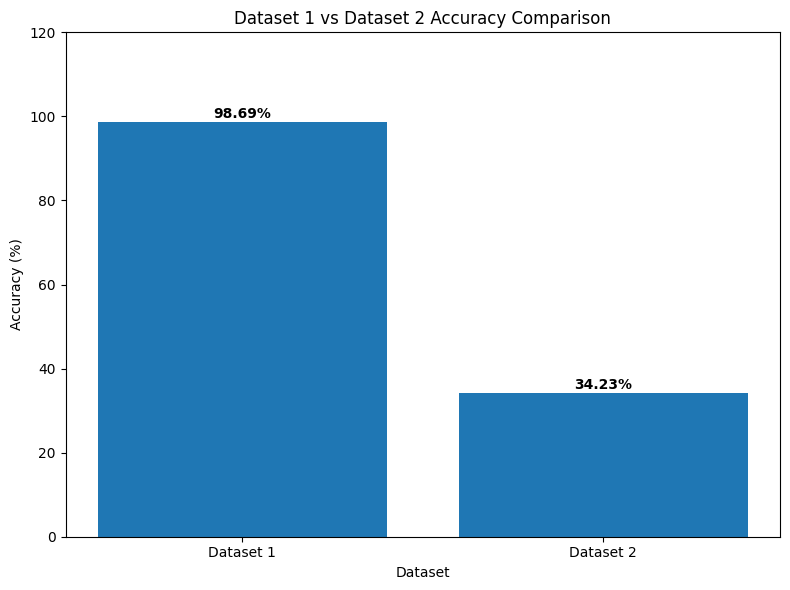

In [ ]:


plt.figure(figsize=(8, 6))

bars = plt.bar(
    ["Dataset 1", "Dataset 2"],
    [
        dataset1_accuracy * 100,
        dataset2_accuracy * 100
    ]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.title("Dataset 1 vs Dataset 2 Accuracy Comparison")

plt.ylim(0, 120)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

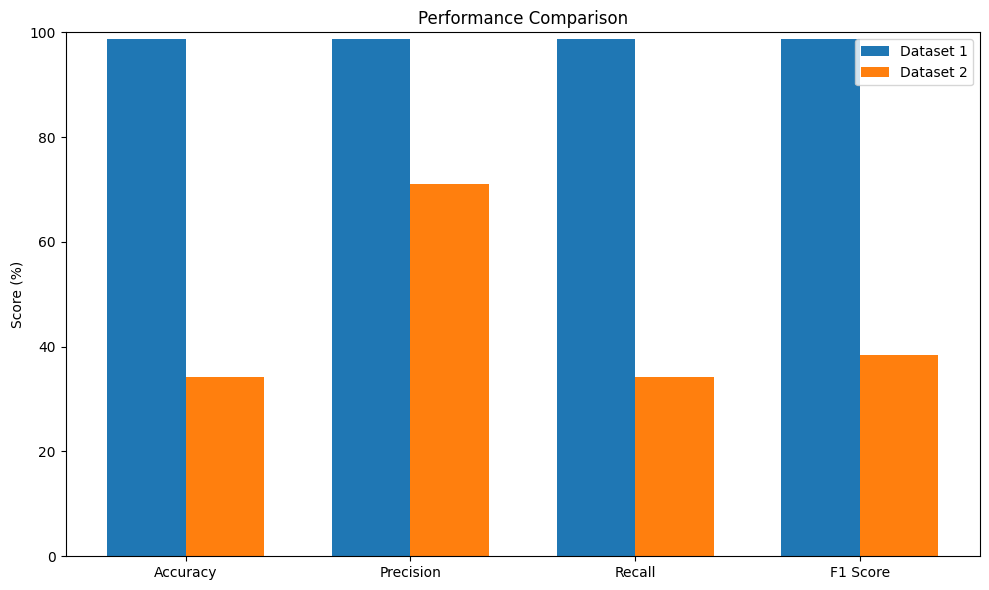

In [ ]:


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

gtsrb_values = [
    dataset1_accuracy,
    dataset1_precision,
    dataset1_recall,
    dataset1_f1
]

brsdd_values = [
    dataset2_accuracy,
    dataset2_precision,
    dataset2_recall,
    dataset2_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    np.array(gtsrb_values) * 100,
    width,
    label="Dataset 1"
)

plt.bar(
    x + width / 2,
    np.array(brsdd_values) * 100,
    width,
    label="Dataset 2"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score (%)")
plt.title("Performance Comparison")

plt.ylim(0, 100)

plt.legend()

plt.tight_layout()
plt.show()

,Dataset,Result,Count
0,Dataset 1,Correct,7739
1,Dataset 1,Incorrect,103
2,Dataset 2,Correct,89
3,Dataset 2,Incorrect,171


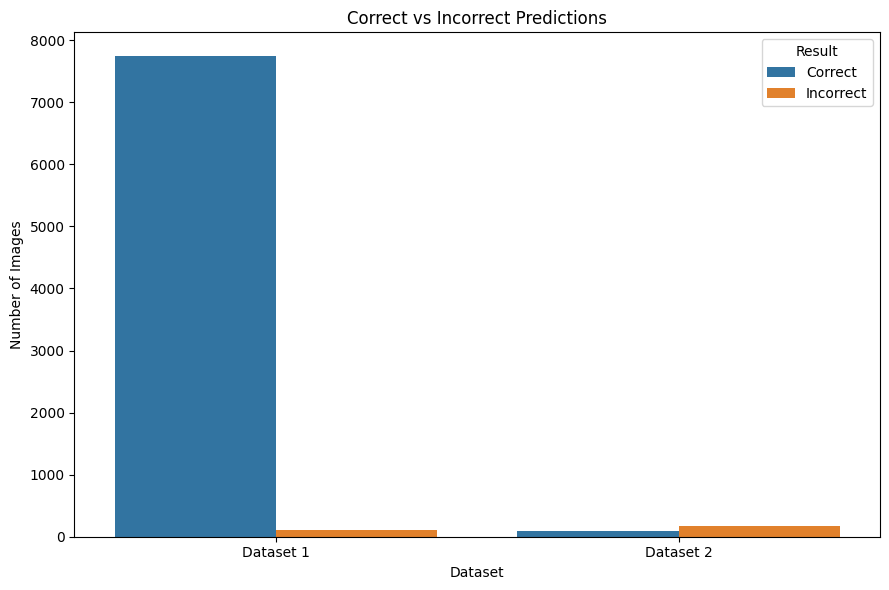

In [ ]:


gtsrb_correct = np.sum(
    gtsrb_y_true == gtsrb_y_pred
)

gtsrb_incorrect = np.sum(
    gtsrb_y_true != gtsrb_y_pred
)

brsdd_correct = np.sum(
    brsdd_y_true == brsdd_y_pred
)

brsdd_incorrect = np.sum(
    brsdd_y_true != brsdd_y_pred
)

correct_data = pd.DataFrame({
    "Dataset": [
        "Dataset 1",
        "Dataset 1",
        "Dataset 2",
        "Dataset 2"
    ],
    "Result": [
        "Correct",
        "Incorrect",
        "Correct",
        "Incorrect"
    ],
    "Count": [
        gtsrb_correct,
        gtsrb_incorrect,
        brsdd_correct,
        brsdd_incorrect
    ]
})

display(correct_data)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=correct_data,
    x="Dataset",
    y="Count",
    hue="Result"
)

plt.title("Correct vs Incorrect Predictions")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [ ]:


used_classes = sorted(
    set(brsdd_y_true)
)

target_names = [
    GTSRB_CLASSES[i]
    for i in used_classes
]

print(
    classification_report(
        brsdd_y_true,
        brsdd_y_pred,
        labels=used_classes,
        target_names=target_names,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

  Speed limit 20 km/h       0.00      0.00      0.00         3
  Speed limit 80 km/h       0.50      0.04      0.07        27
           No passing       0.00      0.00      0.00        50
                Yield       0.74      0.93      0.82        15
             No entry       1.00      1.00      1.00        21
 Dangerous curve left       1.00      0.23      0.38        26
Dangerous curve right       0.84      0.70      0.76        30
           Bumpy road       1.00      0.74      0.85        31
          Pedestrians       1.00      0.05      0.10        57

            micro avg       0.86      0.34      0.49       260
            macro avg       0.68      0.41      0.44       260
         weighted avg       0.71      0.34      0.38       260



In [ ]:


print(
    classification_report(
        gtsrb_y_true,
        gtsrb_y_pred,
        labels=list(range(43)),
        target_names=[
            GTSRB_CLASSES[i]
            for i in range(43)
        ],
        zero_division=0
    )
)

                                             precision    recall  f1-score   support

                        Speed limit 20 km/h       1.00      0.81      0.89        42
                        Speed limit 30 km/h       0.98      1.00      0.99       444
                        Speed limit 50 km/h       1.00      0.99      0.99       450
                        Speed limit 60 km/h       0.99      0.95      0.97       282
                        Speed limit 70 km/h       0.99      0.99      0.99       396
                        Speed limit 80 km/h       0.94      0.98      0.96       372
                 End of speed limit 80 km/h       1.00      1.00      1.00        84
                       Speed limit 100 km/h       0.99      0.99      0.99       288
                       Speed limit 120 km/h       0.98      0.99      0.98       282
                                 No passing       1.00      1.00      1.00       294
      No passing for vehicles over 3.5 tons       1.00      1.00

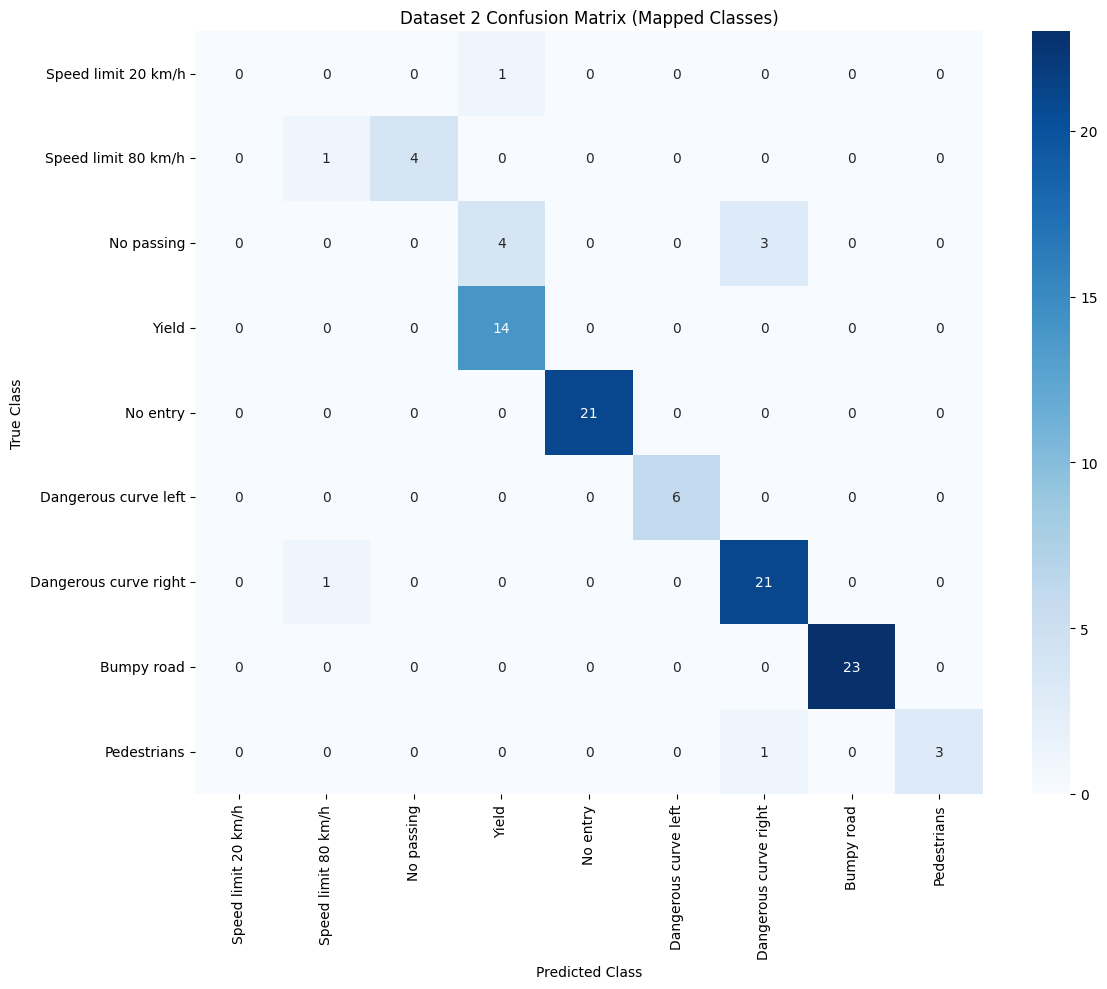

In [ ]:


cm_brsdd = confusion_matrix(
    brsdd_y_true,
    brsdd_y_pred,
    labels=used_classes
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_brsdd,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=[
        GTSRB_CLASSES[i]
        for i in used_classes
    ],
    yticklabels=[
        GTSRB_CLASSES[i]
        for i in used_classes
    ]
)

plt.title(
    "Dataset 2 Confusion Matrix "
    "(Mapped Classes)"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:


per_class_results = []

for class_id in used_classes:

    mask = brsdd_y_true == class_id

    total = np.sum(mask)

    correct = np.sum(
        brsdd_y_pred[mask] == class_id
    )

    accuracy = (
        correct / total
        if total > 0
        else 0
    )

    per_class_results.append({
        "Dataset 1 Class ID": class_id,
        "Class Name": GTSRB_CLASSES[class_id],
        "Total Images": total,
        "Correct": correct,
        "Incorrect": total - correct,
        "Accuracy (%)": accuracy * 100
    })

per_class_df = pd.DataFrame(
    per_class_results
)

display(
    per_class_df.sort_values(
        "Accuracy (%)",
        ascending=False
    )
)

,GDataset 1 Class ID,Class Name,Total Images,Correct,Incorrect,Accuracy (%)
4,17,No entry,21,21,0,100.000000
3,13,Yield,15,14,1,93.333333
7,22,Bumpy road,31,23,8,74.193548
6,20,Dangerous curve right,30,21,9,70.000000
5,19,Dangerous curve left,26,6,20,23.076923
8,27,Pedestrians,57,3,54,5.263158
1,5,Speed limit 80 km/h,27,1,26,3.703704
0,0,Speed limit 20 km/h,3,0,3,0.000000
2,9,No passing,50,0,50,0.000000


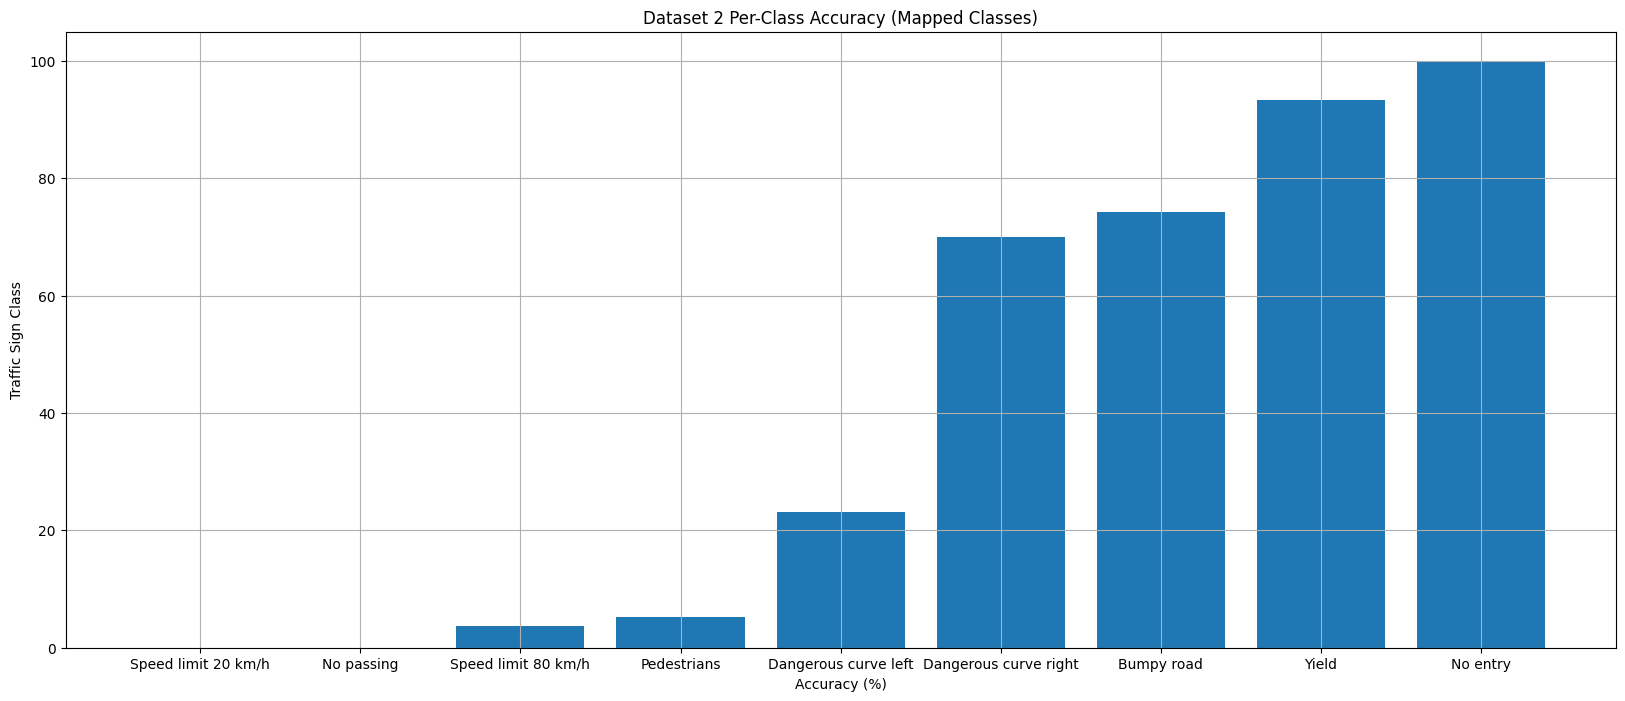

In [ ]:


plot_df = per_class_df.sort_values(
    "Accuracy (%)",
    ascending=True
)

plt.figure(figsize=(20, 8))

plt.bar(
    plot_df["Class Name"],
    plot_df["Accuracy (%)"]
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Traffic Sign Class")

plt.title(
    "Dataset 2 Per-Class Accuracy "
    "(Mapped Classes)"
)
plt.grid ()
plt.show()

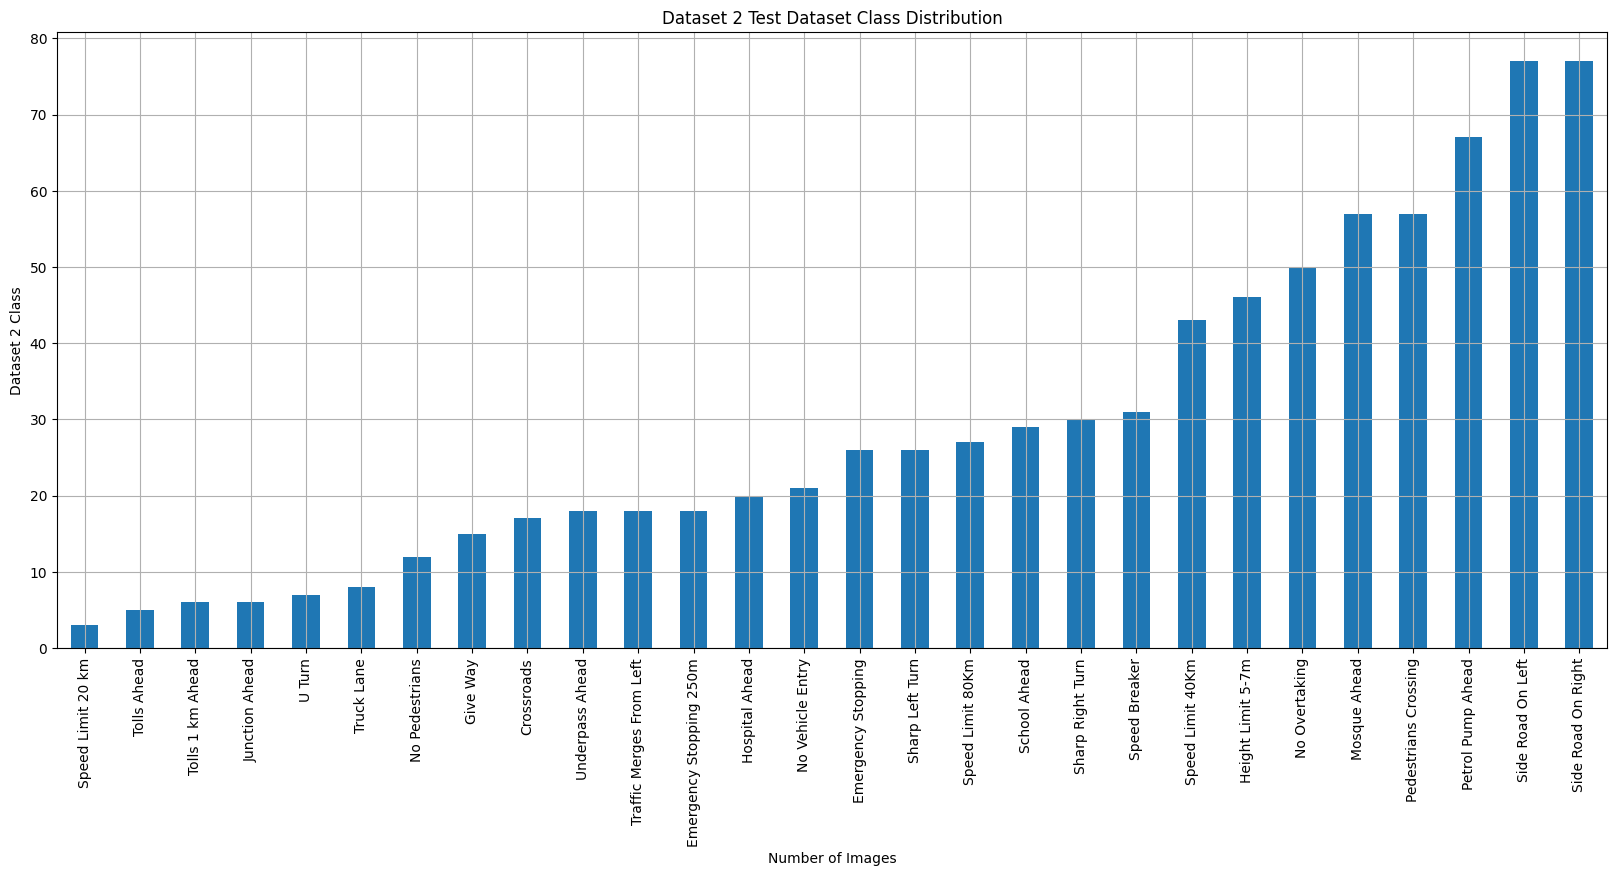

In [ ]:
class_counts = df["class"].value_counts()

plt.figure(figsize=(20, 8))

class_counts.sort_values().plot(
    kind="bar"
)

plt.xlabel("Number of Images")
plt.ylabel("Dataset 2 Class")

plt.title(
    "Dataset 2 Test Dataset Class Distribution"
)

plt.grid()
plt.show()

In [ ]:

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "Dataset1 to Dataset2_Results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

comparison.to_csv(
    os.path.join(
        RESULTS_DIR,
        "dataset_comparison.csv"
    ),
    index=False
)


per_class_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "brsdd_per_class_results.csv"
    ),
    index=False
)


prediction_df = pd.DataFrame({
    "filename": filenames_brsdd,
    "true_class_id": brsdd_y_true,
    "true_class_name": [
        GTSRB_CLASSES[i]
        for i in brsdd_y_true
    ],
    "predicted_class_id": brsdd_y_pred,
    "predicted_class_name": [
        GTSRB_CLASSES[i]
        for i in brsdd_y_pred
    ],
    "correct": (
        brsdd_y_true == brsdd_y_pred
    )
})

prediction_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "brsdd_predictions.csv"
    ),
    index=False
)

print(
    "Results saved to:"
)

print(RESULTS_DIR)

Results saved to:
/content/drive/MyDrive/Dataset1 to Dataset2_Results


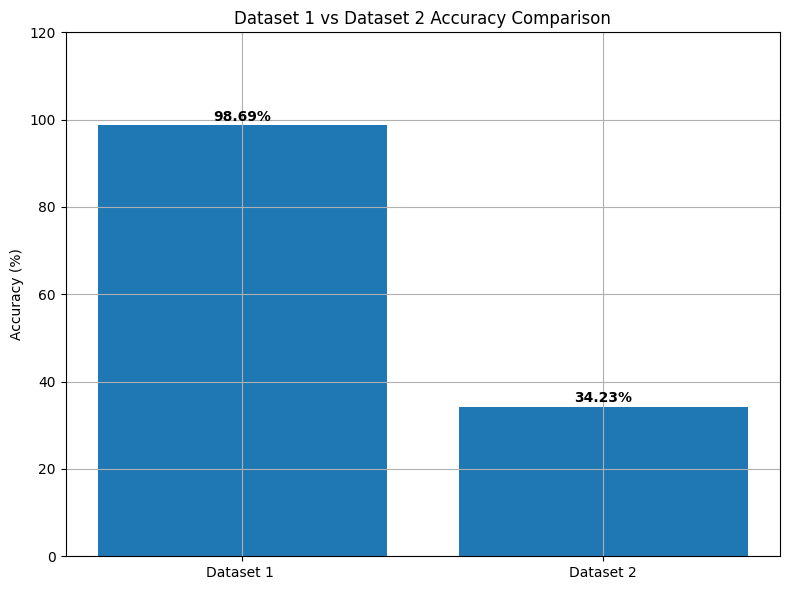

In [ ]:


plt.figure(figsize=(8, 6))

bars = plt.bar(
    ["Dataset 1 ", "Dataset 2"],
    [
        dataset1_accuracy * 100,
        dataset2_accuracy * 100
    ]
)

plt.ylabel("Accuracy (%)")
plt.title(
    "Dataset 1 vs Dataset 2 Accuracy Comparison"
)

plt.ylim(0, 120)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.grid ()
plt.show()

In [ ]:


print("FINAL MODEL EVALUATION")


print("DATASET 1:")

print(f"Accuracy : {dataset1_accuracy * 100:.2f}%")
print(f"Precision: {dataset1_precision * 100:.2f}%")
print(f"Recall   : {dataset1_recall * 100:.2f}%")
print(f"F1 Score : {dataset1_f1 * 100:.2f}%")

print("DATASET 2:")

print(f"Accuracy : {dataset2_accuracy * 100:.2f}%")
print(f"Precision: {dataset2_precision * 100:.2f}%")
print(f"Recall   : {dataset2_recall * 100:.2f}%")
print(f"F1 Score : {dataset2_f1 * 100:.2f}%")

print("\nCOMPARISON")


print(
    f"Accuracy difference: "
    f"{accuracy_difference * 100:.2f} percentage points"
)

print(
    f"Relative accuracy drop: "
    f"{relative_drop:.2f}%"
)

print(
    f"\nDataset 2  mapped classes: "
    f"{len(mapped_classes)} / "
    f"{len(all_brsdd_classes)}"
)

print(
    f"Dataset 2  evaluated images: "
    f"{len(X_brsdd)}"
)



FINAL MODEL EVALUATION
DATASET 1:
Accuracy : 98.69%
Precision: 98.74%
Recall   : 98.69%
F1 Score : 98.66%
DATASET 2:
Accuracy : 34.23%
Precision: 71.06%
Recall   : 34.23%
F1 Score : 38.45%

COMPARISON
Accuracy difference: 64.46 percentage points
Relative accuracy drop: 65.31%

Dataset 2  mapped classes: 9 / 28
Dataset 2  evaluated images: 260
